Loading data...
Training data shape: (61609, 62)
Test data shape: (41074, 61)


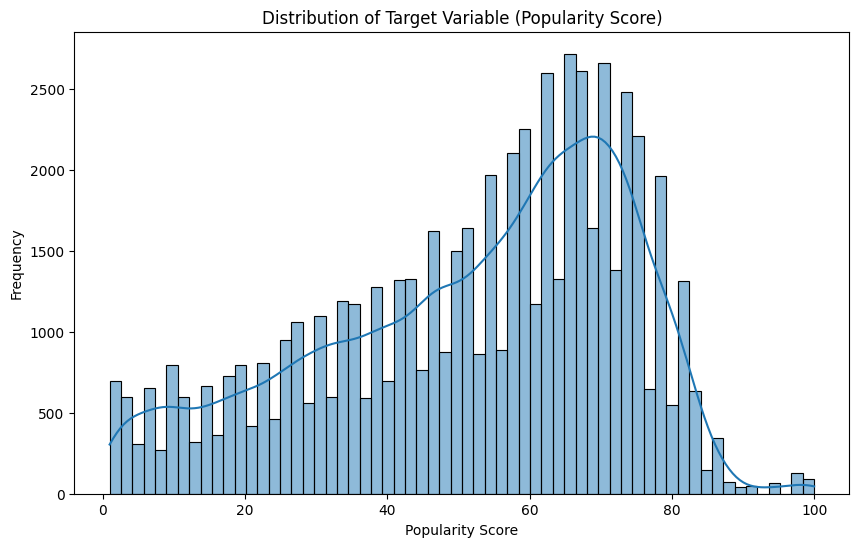


Engineering features...

Numeric columns: 97
Categorical columns: 6

Training set shape: (49287, 103)
Validation set shape: (12322, 103)

--- Training XGBoost Model with Hyperparameter Tuning ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

# Load the data
print("Loading data...")
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Display basic information
print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Exploratory Data Analysis
def plot_target_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['target'], kde=True)
    plt.title('Distribution of Target Variable (Popularity Score)')
    plt.xlabel('Popularity Score')
    plt.ylabel('Frequency')
    plt.show()

if 'target' in train_data.columns:
    plot_target_distribution(train_data)

# Feature Engineering
def engineer_features(df):
    # Create a copy to avoid modifying the original dataframe
    df_processed = df.copy()
    
    # Extract date features from publication_timestamp
    if 'publication_timestamp' in df_processed.columns:
        df_processed['publication_timestamp'] = pd.to_datetime(df_processed['publication_timestamp'])
        df_processed['year'] = df_processed['publication_timestamp'].dt.year
        df_processed['month'] = df_processed['publication_timestamp'].dt.month
        df_processed['day'] = df_processed['publication_timestamp'].dt.day
        df_processed['day_of_week'] = df_processed['publication_timestamp'].dt.dayofweek
        df_processed['is_weekend'] = df_processed['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
        df_processed['quarter'] = df_processed['publication_timestamp'].dt.quarter
    
    # Count number of artists
    if 'creator_collective' in df_processed.columns:
        df_processed['artist_count'] = df_processed['creator_collective'].str.count(',') + 1
    
    # Audio features processing
    audio_features = ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 
                      'beat_frequency', 'emotional_charge', 'groove_efficiency', 'organic_immersion']
    
    for feature in audio_features:
        cols = [col for col in df_processed.columns if feature in col]
        if cols:
            df_processed[f'avg_{feature}'] = df_processed[cols].mean(axis=1)
            df_processed[f'std_{feature}'] = df_processed[cols].std(axis=1)
            df_processed[f'max_{feature}'] = df_processed[cols].max(axis=1)
            df_processed[f'min_{feature}'] = df_processed[cols].min(axis=1)
            df_processed[f'range_{feature}'] = df_processed[f'max_{feature}'] - df_processed[f'min_{feature}']
    
    # Track title length
    if 'track_identifier' in df_processed.columns:
        df_processed['title_length'] = df_processed['track_identifier'].str.len()
        df_processed['title_word_count'] = df_processed['track_identifier'].str.count(' ') + 1
    
    # Interaction features
    if 'avg_rhythmic_cohesion' in df_processed.columns and 'avg_intensity_index' in df_processed.columns:
        df_processed['rhythm_intensity_interaction'] = df_processed['avg_rhythmic_cohesion'] * df_processed['avg_intensity_index']
    
    if 'avg_organic_texture' in df_processed.columns and 'avg_emotional_charge' in df_processed.columns:
        df_processed['texture_emotion_interaction'] = df_processed['avg_organic_texture'] * df_processed['avg_emotional_charge']
    
    # Drop columns that won't be used for modeling
    cols_to_drop = ['track_identifier', 'creator_collective', 'publication_timestamp']
    cols_to_drop = [col for col in cols_to_drop if col in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop)
    
    return df_processed

# Apply feature engineering
print("\nEngineering features...")
train_processed = engineer_features(train_data)
test_processed = engineer_features(test_data)

# Separate features and target
X = train_processed.drop('target', axis=1) if 'target' in train_processed.columns else train_processed
y = train_processed['target'] if 'target' in train_processed.columns else None

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', RobustScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

# Define evaluation function
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.ones(len(y_true)), np.abs(y_true)))) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")
    
    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel('Actual Popularity')
    plt.ylabel('Predicted Popularity')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()
    
    # Plot residuals
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Popularity')
    plt.ylabel('Residuals')
    plt.title(f'{model_name}: Residuals Plot')
    plt.show()
    
    return rmse, mae, r2, mape

# Model 1: XGBoost with Hyperparameter Tuning
print("\n--- Training XGBoost Model with Hyperparameter Tuning ---")

# Define the XGBoost pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(xgb.XGBRegressor(random_state=42))),
    ('regressor', xgb.XGBRegressor(random_state=42))
])

# Define the parameter grid for hyperparameter tuning
xgb_param_dist = {
    'regressor__n_estimators': randint(100, 500),
    'regressor__max_depth': randint(3, 10),
    'regressor__learning_rate': uniform(0.01, 0.3),
    'regressor__subsample': uniform(0.6, 0.4),
    'regressor__colsample_bytree': uniform(0.6, 0.4),
    'regressor__min_child_weight': randint(1, 10),
    'regressor__gamma': uniform(0, 1),
    'feature_selection__threshold': uniform(0.01, 0.2)
}

# Create the randomized search object
xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the randomized search
xgb_random_search.fit(X_train, y_train)

# Print the best parameters
print("\nBest XGBoost Parameters:")
print(xgb_random_search.best_params_)

# Get the best model
xgb_best_model = xgb_random_search.best_estimator_

# Make predictions
xgb_preds = xgb_best_model.predict(X_val)
xgb_metrics = evaluate_model(y_val, xgb_preds, "XGBoost (Tuned)")

# Model 2: Gradient Boosting Regressor
print("\n--- Training Gradient Boosting Regressor ---")

# Define the Gradient Boosting pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Define the parameter grid for hyperparameter tuning
gb_param_dist = {
    'regressor__n_estimators': randint(100, 500),
    'regressor__max_depth': randint(3, 10),
    'regressor__learning_rate': uniform(0.01, 0.3),
    'regressor__subsample': uniform(0.6, 0.4),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10)
}

# Create the randomized search object
gb_random_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the randomized search
gb_random_search.fit(X_train, y_train)

# Print the best parameters
print("\nBest Gradient Boosting Parameters:")
print(gb_random_search.best_params_)

# Get the best model
gb_best_model = gb_random_search.best_estimator_

# Make predictions
gb_preds = gb_best_model.predict(X_val)
gb_metrics = evaluate_model(y_val, gb_preds, "Gradient Boosting (Tuned)")

# Compare models
print("\n--- Model Comparison ---")
models = ['XGBoost (Tuned)', 'Gradient Boosting (Tuned)']
rmse_values = [xgb_metrics[0], gb_metrics[0]]
mae_values = [xgb_metrics[1], gb_metrics[1]]
r2_values = [xgb_metrics[2], gb_metrics[2]]
mape_values = [xgb_metrics[3], gb_metrics[3]]

comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'R²': r2_values,
    'MAPE (%)': mape_values
})
print(comparison_df)

# Plot comparison
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='Model', y='RMSE', data=comparison_df)
plt.title('RMSE (lower is better)')

plt.subplot(2, 2, 2)
sns.barplot(x='Model', y='MAE', data=comparison_df)
plt.title('MAE (lower is better)')

plt.subplot(2, 2, 3)
sns.barplot(x='Model', y='R²', data=comparison_df)
plt.title('R² Score (higher is better)')

plt.subplot(2, 2, 4)
sns.barplot(x='Model', y='MAPE (%)', data=comparison_df)
plt.title('MAPE % (lower is better)')

plt.tight_layout()
plt.show()

# Generate predictions on test data
print("\nGenerating predictions on test data...")
best_model = xgb_best_model if xgb_metrics[0] < gb_metrics[0] else gb_best_model
test_preds = best_model.predict(test_processed)

# Create submission file
submission = pd.DataFrame({
    'id': test_data['id'] if 'id' in test_data.columns else range(len(test_preds)),
    'target': test_preds
})

# Ensure predictions are within the valid range (0-100)
submission['target'] = submission['target'].clip(0, 100)

# Save submission file
submission.to_csv('submission2.csv', index=False)
print("Submission file created successfully!")

# Feature importance analysis for the best model
if best_model == xgb_best_model:
    model_name = "XGBoost"
    if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
        # Get feature names after preprocessing and feature selection
        selected_features = best_model.named_steps['feature_selection'].get_support()
        
        # Get all feature names after preprocessing
        preprocessor = best_model.named_steps['preprocessor']
        cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_cols)
        all_feature_names = numeric_cols + list(cat_features)
        
        # Filter to only selected features
        if len(selected_features) == len(all_feature_names):
            selected_feature_names = [all_feature_names[i] for i in range(len(all_feature_names)) if selected_features[i]]
            
            # Get feature importances
            importances = best_model.named_steps['regressor'].feature_importances_
            
            if len(importances) == len(selected_feature_names):
                # Create a DataFrame for visualization
                feature_importance = pd.DataFrame({
                    'Feature': selected_feature_names,
                    'Importance': importances
                })
                
                # Sort by importance
                feature_importance = feature_importance.sort_values('Importance', ascending=False).head(20)
                
                # Plot
                plt.figure(figsize=(12, 8))
                sns.barplot(x='Importance', y='Feature', data=feature_importance)
                plt.title(f'{model_name} Feature Importance')
                plt.tight_layout()
                plt.show()
else:
    model_name = "Gradient Boosting"
    if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
        # Get feature names after preprocessing
        preprocessor = best_model.named_steps['preprocessor']
        cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_cols)
        feature_names = numeric_cols + list(cat_features)
        
        # Get feature importances
        importances = best_model.named_steps['regressor'].feature_importances_
        
        if len(importances) == len(feature_names):
            # Create a DataFrame for visualization
            feature_importance = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            })
            
            # Sort by importance
            feature_importance = feature_importance.sort_values('Importance', ascending=False).head(20)
            
            # Plot
            plt.figure(figsize=(12, 8))
            sns.barplot(x='Importance', y='Feature', data=feature_importance)
            plt.title(f'{model_name} Feature Importance')
            plt.tight_layout()
            plt.show()

print("\nAnalysis complete!")